In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [13]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/uniform/1MB/90Util/round2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'


/tmp/ipykernel_12023/3670030996.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.17744131
 9019.17744131 9019.17744131 9019.17744131 9019.17744131 9019.

46079
Min Idx: 
261
Average1: 1
Average2: 139


1.209662624002716
138.78462014794727
Time taken: 138.25


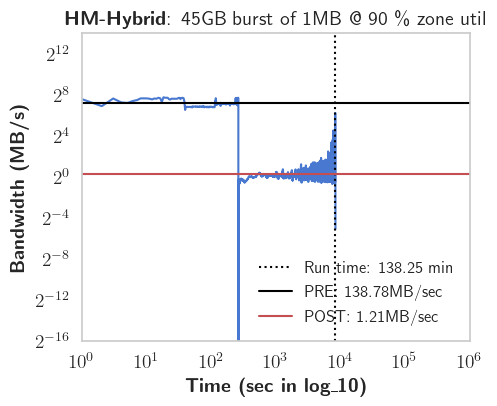

In [17]:

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
#sns.set_style("ticks") 
sns.set_palette("muted")
#sns.set_context("talk")
plt.figure(figsize=(5, 4))
plt.grid(False)

print(str(average_mode1))
print(str(average_mode2))

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

#plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)

print("Time taken: " + str(xmin))
plt.title(r"$\textbf{HM-Hybrid}$: 45GB burst of 1MB @ 90 \% zone util")
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped)

ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
ax.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
ax.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)


common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

plt.legend(loc='lower right', fontsize=12, frameon=False)

plt.savefig('/home/surbhi/Downloads/1M_90Util_HMHybrid_uniform_BW.pdf', bbox_inches='tight', format="pdf")